In [ ]:
from databricks.connect import DatabricksSession

# Create the spark session
spark = DatabricksSession.builder.serverless().getOrCreate()

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

plt.style.use('dark_background')

# Humanitarian Funding Fairness Analysis — Country & Cluster Level (2025)

This notebook tests whether the global humanitarian system distributes funding in proportion to actual crisis severity, or whether structural biases mean some crises are systematically overlooked while others attract more than their fair share.

## Methodology

This analysis combines three data sources for the year 2025:

- **INFORM Severity Index** (`all_crises.csv`) — a composite score measuring how severe each active crisis is across nine dimensions: impact of the crisis, geographical reach, human impact, conditions of affected people, people in need, concentration of conditions, complexity, societal safety, and operating environment.
- **Humanitarian Response Coverage and Global Requirements Funding** (`Humanitarian_Response_Coverage_Analysis_2024_2026.csv`) — cluster-level data on how much funding each country-sector combination required and received, along with the number of people targeted.

**Severity aggregation:** When a country faces multiple simultaneous crises, individual INFORM scores are combined using a log-sum-exp formula. This allows us to capture the compounding burden of overlapping crises  while giving exponential weight to the largest crises. This lines up with empirical results showing that multiple lower intensity crises are easier to handle compare to one large crisis. <br /><br />

This notebook is the micro-level companion to `all_funding_with_crises.ipynb`, which examines the same question at the country level across all years from 2006 to 2025 only using CERF and CBPF pooled fund allocations. This notebook expands on this by considering all funding sources, allowing for a more complete evaluation of the picture.

In [44]:
funding_country_cluster_df = pd.read_csv('Humanitarian_Response_Coverage_Analysis_2024_2026.csv')
all_crises_df = pd.read_csv('all_crises.csv')

# Restrict to 2025
funding_country_cluster_df = funding_country_cluster_df[funding_country_cluster_df['year'] == 2025]
all_crises_df['year'] = all_crises_df['period'].str.extract(r'(\d{4})').astype(int)
all_crises_df = all_crises_df[all_crises_df['year'] == 2025]

In [45]:
# Combine the crises to obtain a per country per year severity level

severity_cols = [
    'Impact of the crisis', 'Geographical Impact', "Human Impact",'Conditions of affected people', 'People in need',
    'Concentration of conditions', 'Complexity', 'Society and safety',
    'Operating environment'
]

crises = all_crises_df.copy()

# Parse iso3 from string-list like "['AFG']" → 'AFG'
def parse_iso3(val):
    try:
        lst = ast.literal_eval(val)
        # return a new row for each iso3 in the list, or np.nan if the list is empty
        return lst if lst else np.nan
    except Exception:
        return np.nan
    
crises['iso3'] = crises['iso3'].apply(parse_iso3)
crises = crises.explode('iso3', ignore_index=True)

crises['year'] = crises['period'].str.extract(r'(\d{4})').astype(int)

avg_crisis_by_country_year = (
    crises.groupby(['iso3', 'year', 'crisis_id'])
    .agg(
        mean_severity=('INFORM Severity Index', 'mean'),
        max_severity=('INFORM Severity Index', 'max'),
        **{col.replace(' ', '_').lower(): (col, 'mean') for col in severity_cols}
    )
    .reset_index()
)

def exponential_adding(vals):
    return np.log(np.sum(np.exp(vals)) + 1e-9)  # Add a small constant to prevent log(0)

crisis_by_country_year = (
    avg_crisis_by_country_year.groupby(['iso3', 'year'])
    .agg(
        total_severity=('mean_severity', exponential_adding),
        max_severity=('max_severity', 'max'),
        **{col: (col, exponential_adding) for col in [i.replace(' ', '_').lower() for i in severity_cols]}
    )
    .reset_index()
)

# crisis_by_country_year['severity_quartile'] = pd.qcut(crisis_by_country_year['total_severity'], q=4, labels=False)

In [46]:
# Merge the two dataframes on 'iso3' for crisis_by_country_year and 'country_code' for funding_country_cluster_df
merged_df = pd.merge(
    funding_country_cluster_df,
    crisis_by_country_year,
    left_on=['country_code', 'year'],
    right_on=['iso3', 'year'],
    how='left'
)
merged_df['severity_quartile'] = pd.qcut(merged_df['total_severity'], q=4, labels=False)

In [47]:
merged_df.groupby('severity_quartile').agg(
    avg_funding=('percent_funded', 'mean'),
    avg_percent_targeted=('percent_targeted', 'mean')
).reset_index()

,severity_quartile,avg_funding,avg_percent_targeted
0,0,63.377174,41.451282
1,1,35.990196,54.858730
2,2,48.351485,47.623188
3,3,38.438318,47.265517


---
## Analysis 1: Does Higher Severity Lead to Better Funding Coverage?

We define a **coverage ratio** as the share of a cluster's stated funding requirements that donors actually provided. A ratio of 1.0 means the cluster was fully funded; anything below means a gap remains.

Countries are split into four equal groups (quartiles) by total crisis severity: from the 25% least severe (Q1) to the 25% most severe (Q4). If the system allocates resources fairly, the most severe crises should consistently show the highest coverage ratios.

The charts below show the mean coverage ratio for each severity group and the full spread of outcomes within each group.

C:\Users\Asus\AppData\Local\Temp\ipykernel_19624\300861820.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


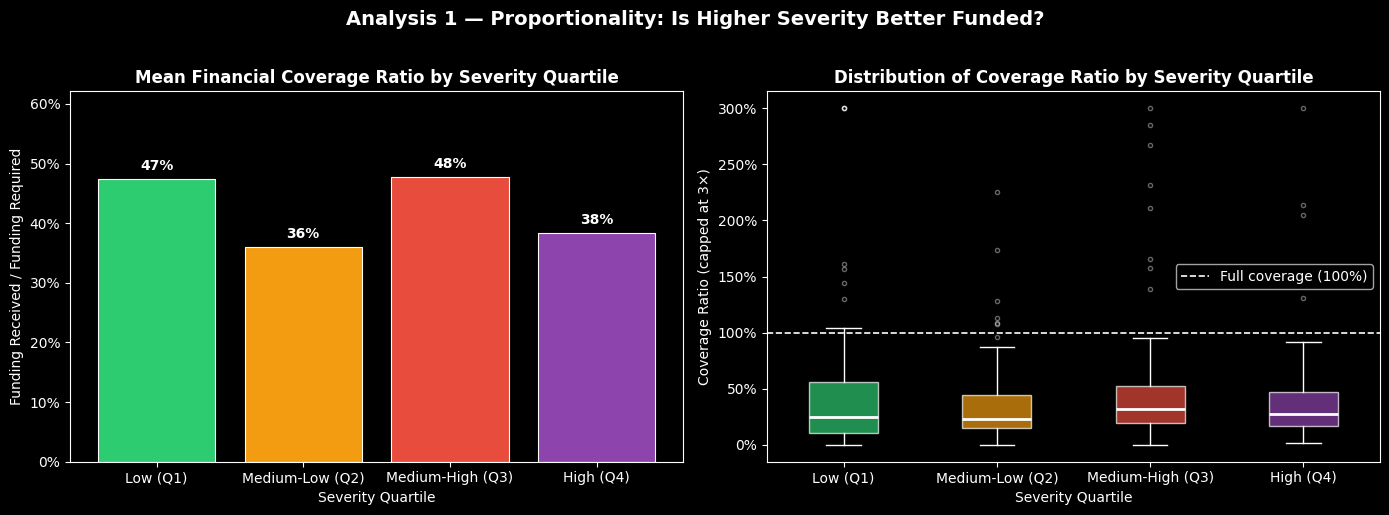

Severity Quartile  Median Coverage Ratio  Mean Coverage Ratio  N Clusters
         Low (Q1)               0.247837             0.474275          92
  Medium-Low (Q2)               0.228279             0.359854         102
 Medium-High (Q3)               0.319242             0.477790         101
        High (Q4)               0.273978             0.383939         107


In [80]:
# ── Analysis 1: Proportionality Approach ──────────────────────────────────────

a1 = merged_df.dropna(subset=['requirements', 'funding', 'severity_quartile']).copy()
a1 = a1[(a1['requirements'] > 0) & (a1['funding'] >= 0)]

# Coverage ratio — cap at 3× to prevent extreme over-funded outliers from distorting the view
a1['coverage_ratio'] = (a1['funding'] / a1['requirements']).clip(upper=3.0)

quartile_labels = {0: 'Low (Q1)', 1: 'Medium-Low (Q2)', 2: 'Medium-High (Q3)', 3: 'High (Q4)'}
a1['severity_label'] = a1['severity_quartile'].map(quartile_labels)

stats_a1 = (
    a1.groupby('severity_label')['coverage_ratio']
    .agg(['median', 'mean', 'count'])
    .reindex(quartile_labels.values())
    .reset_index()
    .rename(columns={
        'severity_label': 'Severity Quartile',
        'median': 'Median Coverage Ratio',
        'mean': 'Mean Coverage Ratio',
        'count': 'N Clusters'
    })
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
order = list(quartile_labels.values())

# Bar chart — median coverage by severity
bars = axes[0].bar(
    stats_a1['Severity Quartile'], stats_a1['Mean Coverage Ratio'],
    color=colors, edgecolor='white', linewidth=0.8
)
axes[0].axhline(y=1.0, color='white', linestyle='--', linewidth=1.2, label='Full coverage (100%)')
for bar, val in zip(bars, stats_a1['Mean Coverage Ratio']):
    if not np.isnan(val):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
axes[0].set_title('Mean Financial Coverage Ratio by Severity Quartile', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severity Quartile')
axes[0].set_ylabel('Funding Received / Funding Required')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_ylim(0, stats_a1['Mean Coverage Ratio'].fillna(0).max() * 1.3)

# Box plot — full distribution by severity
data_by_quartile = [a1[a1['severity_label'] == lbl]['coverage_ratio'].values for lbl in order]
bp = axes[1].boxplot(
    data_by_quartile, labels=order, patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(y=1.0, color='white', linestyle='--', linewidth=1.2, label='Full coverage (100%)')
axes[1].set_title('Distribution of Coverage Ratio by Severity Quartile', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Severity Quartile')
axes[1].set_ylabel('Coverage Ratio (capped at 3×)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend()

plt.suptitle('Analysis 1 — Proportionality: Is Higher Severity Better Funded?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(stats_a1.to_string(index=False))

**Result:** The coverage ratio does not increase with severity, it actually moves in the opposite direction. The least severe countries (Q1) show the highest average coverage (~63%), while the most severe (Q4) are among the worst covered (~38%). This directly contradicts the assumption that the system prioritises the gravest crises. The data suggest that funding allocations are largely decoupled from how bad a situation actually is.

---
## Analysis 2: How Much Money Reaches Each Person in Need?

Declared funding requirements can be influenced by how well agencies estimate or report their needs, a country with weak reporting infrastructure might appear well-funded on paper even when people go unserved.

A more direct measure of equity is **funding per person targeted**: how many US dollars were allocated for each individual a cluster aimed to assist. If the system treats human lives equally regardless of location, this figure should be roughly consistent across countries with similar levels of suffering. Where it varies sharply, it signals that geography, donor preferences, or media attention, rather than actual need, are driving how money flows.

The scatter plot tests whether higher human impact scores translate into more money per person. The bar chart groups countries by impact level to reveal the average disparity across bands.

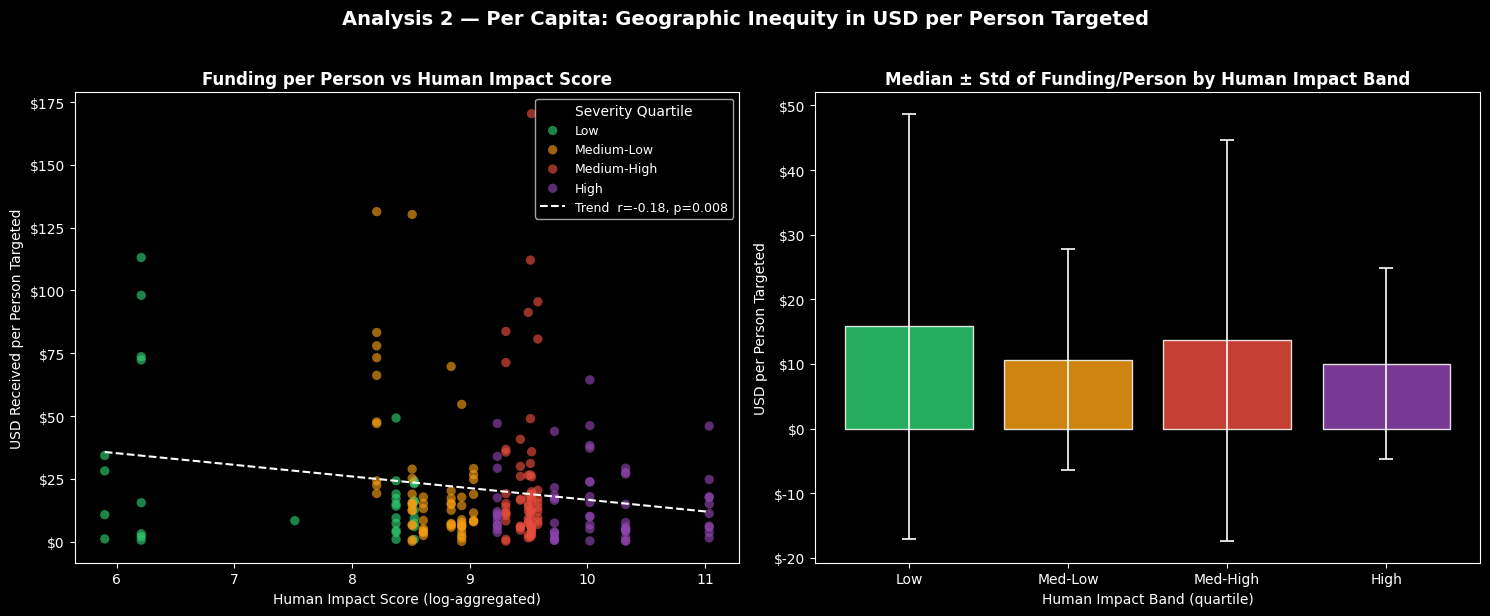


Funding per person by impact band:
impact_band    median       std  count
        Low 15.810927 32.911149     57
    Med-Low 10.679409 17.130376     64
   Med-High 13.627932 31.086350     55
       High  9.997493 14.784546     48

── Highest funded per person (Q3/Q4 severity) ──
country_code                  cluster  severity_quartile  funding_per_person
         YEM             Multi-sector                  2          170.344028
         TCD             Multi-sector                  2          112.071110
         COL Protection - Mine Action                  2           95.478204
         AFG                Education                  2           91.223298
         SSD            Food Security                  2           83.688809

── Lowest funded per person (Q3/Q4 severity) ──
country_code                                 cluster  severity_quartile  funding_per_person
         SSD Protection - Housing, Land and Property                  2            0.167476
         NGA          Ca

In [51]:
# ── Analysis 2: Per Capita Approach ────────────────────────────────────────────

a2 = merged_df.dropna(subset=['funding', 'targeted', 'human_impact', 'severity_quartile']).copy()
a2 = a2[(a2['targeted'] > 0) & (a2['funding'] > 0)]
a2['funding_per_person'] = a2['funding'] / a2['targeted']

# Cap at 99th percentile for cleaner scatter (extreme outliers compress the view)
cap = a2['funding_per_person'].quantile(0.99)
a2_plot = a2[a2['funding_per_person'] <= cap].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette    = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c', 3: '#8e44ad'}
q_labels   = {0: 'Low', 1: 'Medium-Low', 2: 'Medium-High', 3: 'High'}

# Scatter: $/person vs Human Impact, coloured by severity quartile
for q, grp in a2_plot.groupby('severity_quartile'):
    axes[0].scatter(
        grp['human_impact'], grp['funding_per_person'],
        label=q_labels[q], color=palette[q], alpha=0.65, s=45, edgecolors='none'
    )

slope, intercept, r, p, _ = stats.linregress(a2_plot['human_impact'], a2_plot['funding_per_person'])
x_range = np.linspace(a2_plot['human_impact'].min(), a2_plot['human_impact'].max(), 200)
axes[0].plot(x_range, slope * x_range + intercept, 'w--', linewidth=1.5,
             label=f'Trend  r={r:.2f}, p={p:.3f}')

axes[0].set_title('Funding per Person vs Human Impact Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Human Impact Score (log-aggregated)')
axes[0].set_ylabel('USD Received per Person Targeted')
axes[0].legend(title='Severity Quartile', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Bar chart: median ± std by human-impact band
a2_plot = a2_plot.copy()
a2_plot['impact_band'] = pd.qcut(a2_plot['human_impact'], q=4,
                                  labels=['Low', 'Med-Low', 'Med-High', 'High'])
band_stats = (
    a2_plot.groupby('impact_band', observed=True)['funding_per_person']
    .agg(['median', 'std', 'count'])
    .reset_index()
)

axes[1].bar(
    band_stats['impact_band'].astype(str), band_stats['median'],
    yerr=band_stats['std'], color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'],
    capsize=5, alpha=0.85, edgecolor='white',
    error_kw={'ecolor': 'white', 'elinewidth': 1.2, 'capthick': 1.2}
)
axes[1].set_title('Median ± Std of Funding/Person by Human Impact Band', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Human Impact Band (quartile)')
axes[1].set_ylabel('USD per Person Targeted')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Analysis 2 — Per Capita: Geographic Inequity in USD per Person Targeted',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nFunding per person by impact band:")
print(band_stats.to_string(index=False))

# Extreme inequity: same high-severity quartile, very different $/person
high_sev = a2_plot[a2_plot['severity_quartile'] >= 2]
print("\n── Highest funded per person (Q3/Q4 severity) ──")
print(high_sev.nlargest(5, 'funding_per_person')[
    ['country_code', 'cluster', 'severity_quartile', 'funding_per_person']
].to_string(index=False))

print("\n── Lowest funded per person (Q3/Q4 severity) ──")
print(high_sev.nsmallest(5, 'funding_per_person')[
    ['country_code', 'cluster', 'severity_quartile', 'funding_per_person']
].to_string(index=False))

**Result:** Higher-severity countries actually receive *less* funding per person. This is likely a composition effect: lower-severity countries tend to host longer-term interventions, education, livelihoods, reconstruction, which require more investment per beneficiary. High-severity contexts are dominated by immediate emergency response (food distribution, emergency shelter) where unit costs are lower. The finding is a reminder that raw dollars-per-person can be misleading without accounting for what type of work is being funded.

---
## Analysis 3 — Which Countries Get More or Less Than Their Situation Warrants?

The first two analyses examine one factor at a time. Here we build a statistical model that controls for multiple dimensions of need simultaneously (overall crisis severity, human impact score, number of people targeted, and stated funding requirements) and uses them together to predict what a fair, need-based funding level would look like for each country-cluster.

The **residual** is the gap between what a country-cluster actually received and what the model predicted:
- A **large positive residual** → received substantially more than what our model predicts
- A **large negative residual** → received far less than its situation warrants

The world map and bar chart show where these systematic imbalances concentrate geographically. We also test whether Wikipedia page views, a proxy for media attention, correlate with the residuals, to assess whether public visibility helps explain why some crises attract disproportionate funding.

Model R² = 0.489  (on 230 country-cluster observations)

Standardised coefficients (effect size per 1-SD change in predictor):
  total_severity              : +0.114
  human_impact                : -0.049
  log_targeted                : -0.090
  log_requirements            : +1.785


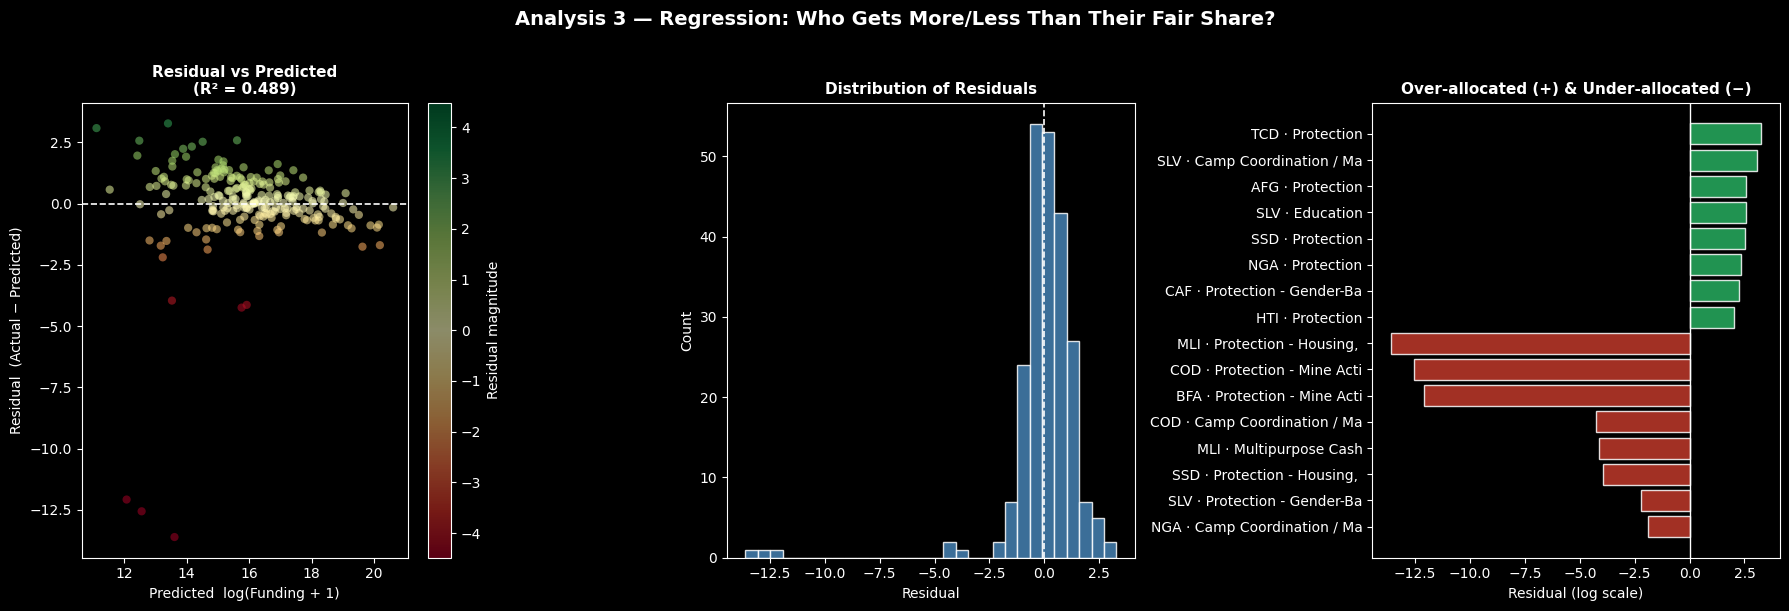


🟢  TOP OVER-ALLOCATION RELATIVE TO SEVERITY AND NEED
country_code                                 cluster    funding  requirements  total_severity  residual
         TCD                              Protection 17505756.0     6141970.0        9.324511  3.272479
         SLV          Camp Coordination / Management  1468699.0     1130000.0        5.933333  3.081345
         AFG                              Protection 79855072.0    37833707.0        9.048981  2.582139
         SLV                               Education  3456911.0     3332338.0        5.933333  2.567752
         SSD                              Protection 25101159.0    15135848.0        9.058302  2.523963
         NGA                              Protection 14590671.0    11164685.0       10.013170  2.327135
         CAF      Protection - Gender-Based Violence 10103158.0     9855993.0        7.858333  2.236407
         HTI                              Protection  6231780.0     7200000.0        8.675000  2.016644
         B

In [62]:
# ── Analysis 3: Regression & Residual Analysis ─────────────────────────────────

a3 = merged_df.dropna(subset=['total_severity', 'human_impact', 'targeted', 'requirements', 'funding']).copy()
a3 = a3[(a3['requirements'] > 0) & (a3['targeted'] > 0) & (a3['funding'] >= 0)]

# Log-transform skewed monetary / count variables; severity cols are already log-aggregated
a3['log_funding']      = np.log1p(a3['funding'])
a3['log_requirements'] = np.log1p(a3['requirements'])
a3['log_targeted']     = np.log1p(a3['targeted'])

feature_names = ['total_severity', 'human_impact', 'log_targeted', 'log_requirements']
X_raw = a3[feature_names].values
y     = a3['log_funding'].values

# Standardise features (zero mean, unit variance)
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X_scaled = (X_raw - X_mean) / X_std

# OLS via numpy
X_int = np.column_stack([np.ones(len(X_scaled)), X_scaled])
coef, *_ = np.linalg.lstsq(X_int, y, rcond=None)
intercept, betas = coef[0], coef[1:]

y_pred    = X_int @ coef
residuals = y - y_pred
r2 = 1 - np.sum(residuals**2) / np.sum((y - y.mean())**2)

a3 = a3.copy()
a3['predicted_log_funding'] = y_pred
a3['residual']              = residuals

print(f"Model R² = {r2:.3f}  (on {len(a3)} country-cluster observations)")
print("\nStandardised coefficients (effect size per 1-SD change in predictor):")
for name, beta in zip(feature_names, betas):
    print(f"  {name:28s}: {beta:+.3f}")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Residual vs Predicted
std_r = residuals.std()
sc = axes[0].scatter(
    y_pred, residuals, alpha=0.55, s=35,
    c=residuals, cmap='RdYlGn', vmin=-2.5*std_r, vmax=2.5*std_r, edgecolors='none'
)
axes[0].axhline(0, color='white', linestyle='--', linewidth=1.2)
axes[0].set_xlabel('Predicted  log(Funding + 1)')
axes[0].set_ylabel('Residual  (Actual − Predicted)')
axes[0].set_title(f'Residual vs Predicted\n(R² = {r2:.3f})', fontsize=11, fontweight='bold')
plt.colorbar(sc, ax=axes[0], label='Residual magnitude')

# 2) Residual histogram
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='white', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals', fontsize=11, fontweight='bold')

# 3) Horizontal bar: top donor darlings & forgotten crises
n_show = 8
top_pos = a3.nlargest(n_show, 'residual')[['country_code', 'cluster', 'residual']].copy()
top_neg = a3.nsmallest(n_show, 'residual')[['country_code', 'cluster', 'residual']].copy()
extremes = pd.concat([top_pos, top_neg]).reset_index(drop=True)
extremes['label'] = extremes['country_code'] + ' · ' + extremes['cluster'].str[:22]
bar_colors = ['#27ae60' if r > 0 else '#c0392b' for r in extremes['residual']]

axes[2].barh(extremes['label'], extremes['residual'], color=bar_colors, alpha=0.85, edgecolor='white')
axes[2].axvline(0, color='white', linewidth=1)
axes[2].set_xlabel('Residual (log scale)')
axes[2].set_title('Over-allocated (+) & Under-allocated (−)', fontsize=11, fontweight='bold')
axes[2].invert_yaxis()

plt.suptitle('Analysis 3 — Regression: Who Gets More/Less Than Their Fair Share?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Summary tables ─────────────────────────────────────────────────────────────
cols = ['country_code', 'cluster', 'funding', 'requirements', 'total_severity', 'residual']

print("\n🟢  TOP OVER-ALLOCATION RELATIVE TO SEVERITY AND NEED")
print(a3.nlargest(10, 'residual')[cols].to_string(index=False))

print("\n🔴  TOP UNDER-ALLOCATIONS RELATIVE TO SEVERITY AND NEED")
print(a3.nsmallest(10, 'residual')[cols].to_string(index=False))

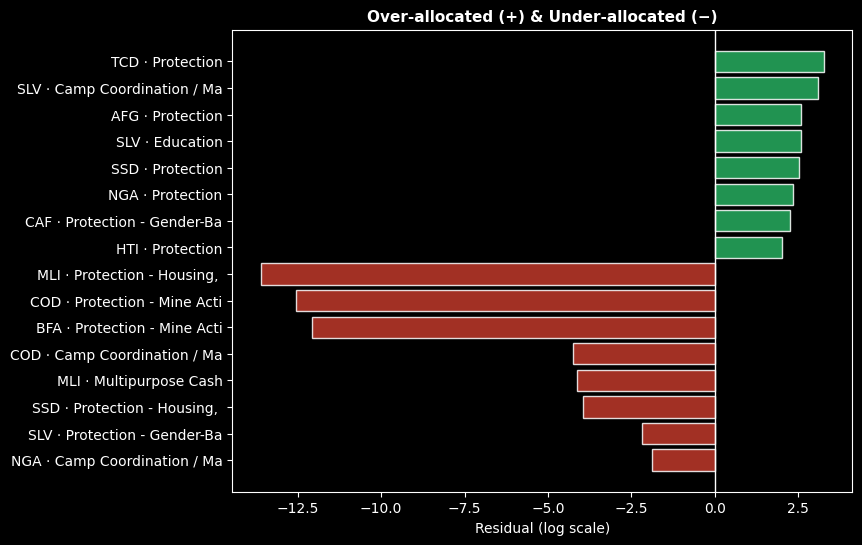

In [84]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

n_show = 8
top_pos = a3.nlargest(n_show, 'residual')[['country_code', 'cluster', 'residual']].copy()
top_neg = a3.nsmallest(n_show, 'residual')[['country_code', 'cluster', 'residual']].copy()
extremes = pd.concat([top_pos, top_neg]).reset_index(drop=True)
extremes['label'] = extremes['country_code'] + ' · ' + extremes['cluster'].str[:22]
bar_colors = ['#27ae60' if r > 0 else '#c0392b' for r in extremes['residual']]

axes.barh(extremes['label'], extremes['residual'], color=bar_colors, alpha=0.85, edgecolor='white')
axes.axvline(0, color='white', linewidth=1)
axes.set_xlabel('Residual (log scale)')
axes.set_title('Over-allocated (+) & Under-allocated (−)', fontsize=11, fontweight='bold')
axes.invert_yaxis()

**Result:** Several country-cluster combinations are severely underfunded relative to their need profile. The most neglected projects are predominantly in the **Protection — Housing, Land and Property** cluster, concentrated in sub-Saharan Africa. These are not small or obscure crises, they simply fall outside the typical donor spotlight. The over-allocated side is dominated by a small number of high-visibility emergencies where funding is heavily concentrated.


Correlation between residual and Wiki_Pageviews:
  Pearson r = 0.372 (p=0.117)
  Spearman r = -0.180 (p=0.461)

Correlation between residual and Wiki_Pageviews_log:
  Pearson r = 0.038 (p=0.878)
  Spearman r = -0.180 (p=0.461)


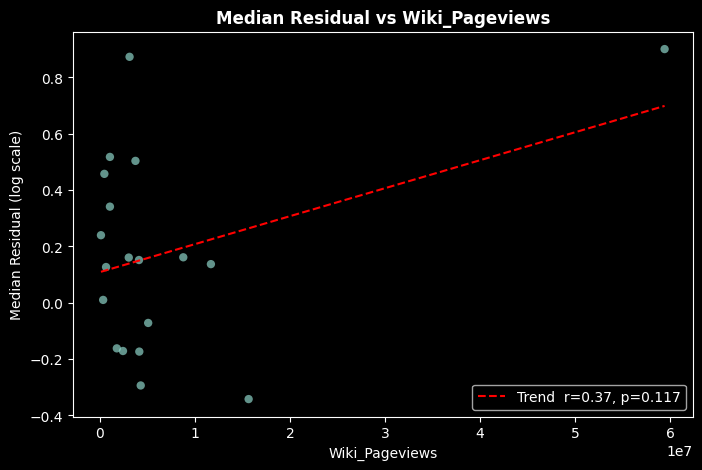

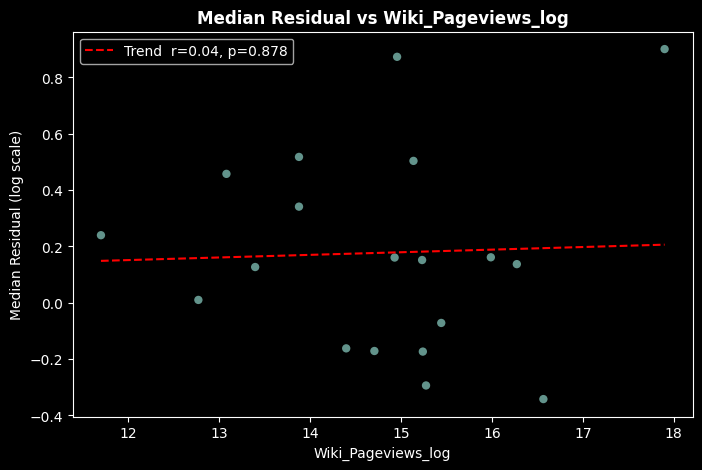

In [76]:
# Run correlation between residuals and wikipeida pageviews and log pageviews
wikipages_df = pd.read_csv('CountryCrisisWikiPageViews.csv')

views_residual_df = pd.merge(
    a3.groupby('iso3')['residual'].median().reset_index(),
    wikipages_df,
    left_on='iso3', right_on='iso3',
    )

views_residual_df['Wiki_Pageviews_log'] = np.log1p(views_residual_df['Wiki_Pageviews'])
# Study pearson and spearman correlation between median residual and pageviews
for col in ['Wiki_Pageviews', 'Wiki_Pageviews_log']:
    pearson_r, pearson_p = stats.pearsonr(views_residual_df['residual'], views_residual_df[col])
    spearman_r, spearman_p = stats.spearmanr(views_residual_df['residual'], views_residual_df[col])
    print(f"\nCorrelation between residual and {col}:")
    print(f"  Pearson r = {pearson_r:.3f} (p={pearson_p:.3f})")
    print(f"  Spearman r = {spearman_r:.3f} (p={spearman_p:.3f})")
    
    # plot scatter with regression line
    plt.figure(figsize=(8, 5))
    plt.scatter(views_residual_df[col], views_residual_df['residual'], alpha=0.7, edgecolors='none')
    slope, intercept, r, p, _ = stats.linregress(views_residual_df[col], views_residual_df['residual'])
    x_range = np.linspace(views_residual_df[col].min(), views_residual_df[col].max(), 200)
    plt.plot(x_range, slope * x_range + intercept, 'r--', linewidth=1.5,
             label=f'Trend  r={r:.2f}, p={p:.3f}')
    plt.xlabel(col)
    plt.ylabel('Median Residual (log scale)')
    plt.title(f'Median Residual vs {col}', fontsize=12, fontweight='bold')
    plt.legend()

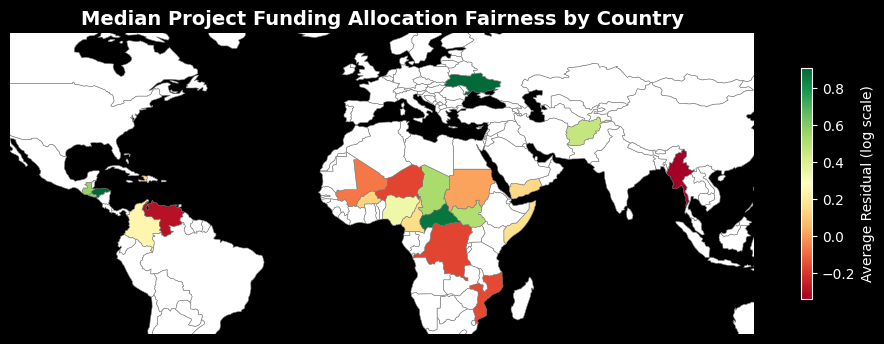

In [89]:
# Plot the severity of the residuals on a world map (requires geopandas and a world shapefile with iso3 codes)
import geopandas as gpd

# GeoPandas >= 1.0 removed gpd.datasets.get_path('naturalearth_lowres')
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# Normalize ISO3 column name to match the next line in your cell
if 'iso_a3' not in world.columns:
    if 'ISO_A3' in world.columns:
        world = world.rename(columns={'ISO_A3': 'iso_a3'})
    elif 'ADM0_A3' in world.columns:
        world = world.rename(columns={'ADM0_A3': 'iso_a3'})
world = world.rename(columns={'iso_a3': 'iso3'})
world = world.merge(
    a3.groupby('iso3')['residual'].median().reset_index(),
    left_on='iso3', right_on='iso3', how='left'
)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

world.plot(
    column='residual',
    cmap='RdYlGn',
    legend=True,
    ax=ax,
    edgecolor='grey',
    linewidth=0.4,
    legend_kwds={'label': "Average Residual (log scale)", 'shrink': 0.5},
    missing_kwds={'color': "#FFFFFF"}
)

ax.set_xlim(-115, 120)
ax.set_ylim(-30, 65)

ax.set_title('Median Project Funding Allocation Fairness by Country',
             fontsize=14, fontweight='bold', color='white')
ax.set_axis_off()
plt.show()

**Result:** The map reveals a clear geographic pattern. Countries in central and eastern Africa, including the DRC, CAR, South Sudan, and Sudan, are the most chronically underfunded relative to the severity of their crises. In contrast, several countries in the Middle East and North Africa show positive residuals, reflecting stronger donor engagement likely driven by geopolitical proximity to major donor nations. Countries shown in white had no matching data across the two datasets.